In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横96pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[129.        , 138.        , 137.        ],
          [123.625     , 124.5625    , 118.1875    ],
          [106.5       ,  97.15625   ,  88.609375  ],
          ...,
          [ 25.46875   ,  33.46875   ,  52.46875   ],
          [ 30.65625   ,  38.328125  ,  57.        ],
          [ 32.        ,  39.        ,  57.        ]],
 
         [[137.0625    , 145.39062   , 147.07812   ],
          [141.16724   , 141.88428   , 138.19678   ],
          [122.278564  , 114.15259   , 112.55542   ],
          ...,
          [ 35.78833   ,  44.460205  ,  61.38159   ],
          [ 38.29883   ,  46.64258   ,  62.406494  ],
          [ 36.03125   ,  43.703125  ,  58.34375   ]],
 
         [[144.625     , 151.71875   , 152.45312   ],
          [157.62158   , 156.41138   , 161.81738   ],
          [138.92651   , 131.79883   , 139.71289   ],
          ...,
          [ 42.633545  ,  50.975098  ,  66.18042   ],
          [ 42.321533  ,  50.688965  ,  64.42383   ],
          [ 39.8125    ,  47.81

In [3]:
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

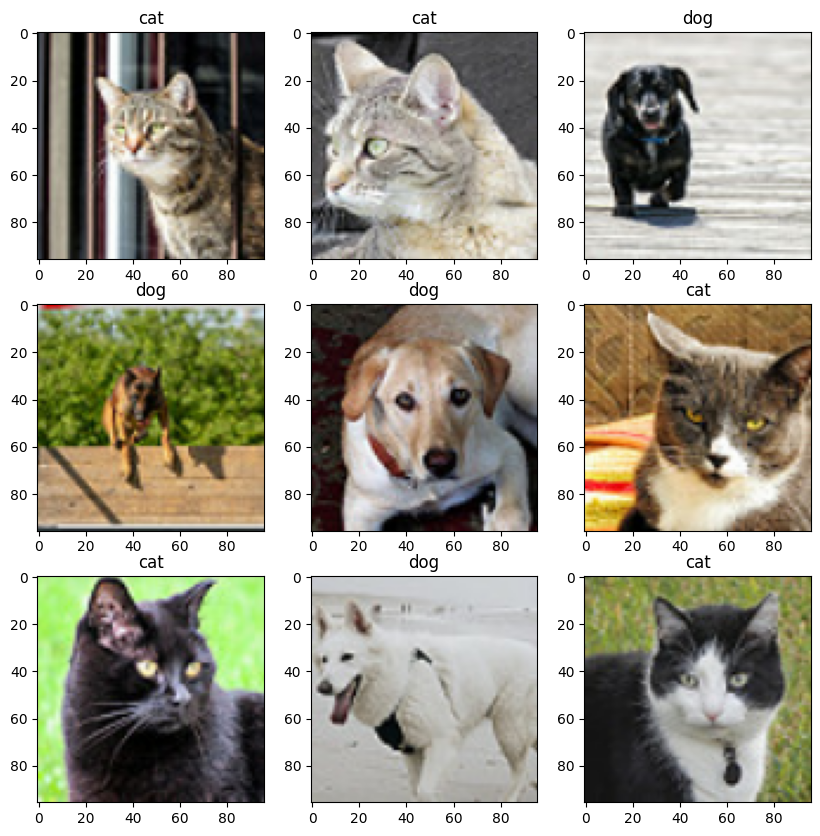

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [6]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [8]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [9]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [10]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

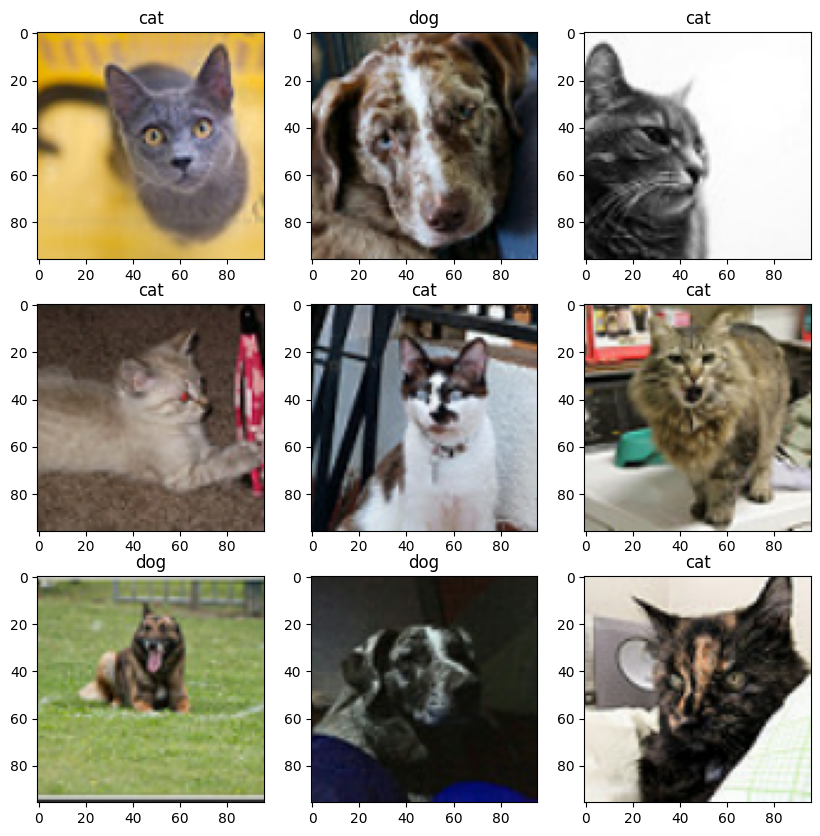

In [11]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [12]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(96, 96, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(96, 96, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [14]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [15]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [16]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.6723 - loss: 0.5943
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.9193 - loss: 0.1918
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9561 - loss: 0.1307
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.9640 - loss: 0.1119
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9751 - loss: 0.0885
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9882 - loss: 0.0711
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9868 - loss: 0.0616
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9913 - loss: 0.0544
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9954 - loss: 0.0422
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9952 - loss: 0.0391
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9984 - loss: 0.0336
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accu

In [ ]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step


In [18]:
pred_data

array([[1.1453370e-03],
       [4.1293327e-04],
       [3.4376735e-05],
       [5.8153182e-05],
       [2.2522938e-03],
       [3.1456156e-03],
       [3.2627091e-04],
       [1.2840526e-03],
       [5.4367090e-04],
       [2.5653030e-04],
       [2.4011711e-04],
       [1.1725500e-02],
       [2.7448373e-04],
       [3.1494915e-01],
       [2.4581718e-04],
       [3.3052123e-04],
       [2.8533581e-01],
       [1.6294211e-03],
       [4.0848073e-04],
       [4.4802553e-04],
       [2.4527521e-04],
       [2.9436357e-03],
       [9.8988261e-05],
       [2.4304069e-04],
       [6.7667949e-01],
       [4.9243405e-05],
       [1.3686104e-03],
       [1.1292836e-04],
       [9.0706460e-02],
       [2.1497388e-03],
       [2.3197883e-03],
       [4.1191640e-01],
       [2.9061621e-06],
       [2.6896576e-04],
       [2.5629571e-03],
       [3.0494961e-01],
       [1.5618441e-01],
       [1.0652482e-05],
       [2.8410618e-04],
       [5.2819285e-04],
       [2.4376172e-04],
       [2.764231

In [19]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9845 - loss: 0.0493


[0.038366492837667465, 0.9900000095367432]